# 3D Segmentation to Minkowski Tensor Analysis

This notebook demonstrates an end-to-end pipeline for analysing 3D cell morphology using Minkowski tensors. Starting from a raw confocal fluorescence stack, we segment individual nuclei, compute their full set of Minkowski tensors with **pykarambola**, colour-code reconstructed 3D meshes by shape anisotropy, and finally cluster the nuclei in a low-dimensional PCA space derived from tensor features.

**Dataset:** `skimage.data.cells3d()` — a 60-slice confocal stack of HeLa cells with two channels (cell membrane and nuclei stained with SYTO 16), acquired at voxel spacing Z = 0.29 µm, Y = X = 0.2645 µm.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy import ndimage
from skimage import data, filters, measure
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pykarambola as pk

Shape: (60, 256, 256)  dtype: uint16
Voxel spacing: Z=0.29 µm, Y=0.2645 µm, X=0.2645 µm


/opt/miniconda3/envs/pykarambola-0.3.0/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


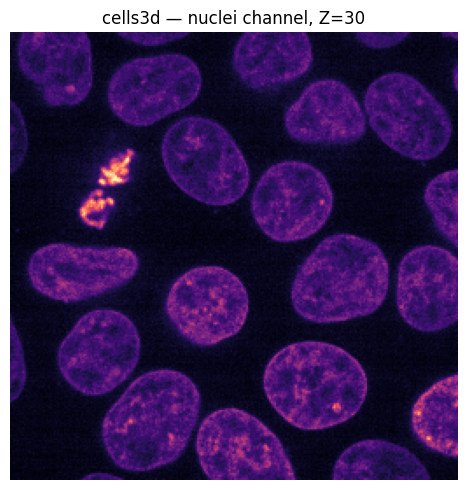

In [2]:
cells = data.cells3d()          # (60, 2, 256, 256) uint16, axes: Z C Y X
nuclei = cells[:, 1, :, :]     # channel 1 = nuclei (SYTO 16)

# physical voxel spacing (Z, Y, X) in µm — from skimage docs
SPACING = (0.29, 0.2645, 0.2645)

print(f"Shape: {nuclei.shape}  dtype: {nuclei.dtype}")
print(f"Voxel spacing: Z={SPACING[0]} µm, Y={SPACING[1]} µm, X={SPACING[2]} µm")

# show mid-Z slice
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(nuclei[30], cmap='magma')
ax.axis('off')
ax.set_title('cells3d — nuclei channel, Z=30')
plt.tight_layout()
plt.show()

## Segmentation

We apply a mild Gaussian blur (σ = 2 voxels) to suppress shot noise, threshold with Otsu's method, fill internal holes, and then run connected-component labelling. Small fragments (< 5 000 voxels) are discarded to keep only complete nuclei.

Detected 12 nuclei after filtering


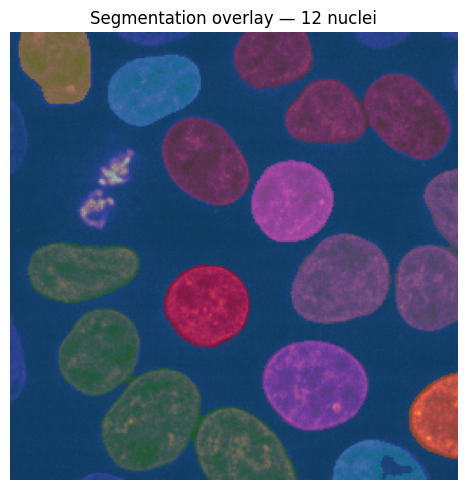

In [3]:
smooth = filters.gaussian(nuclei.astype(float), sigma=2)
thresh = filters.threshold_otsu(smooth)
binary = smooth > thresh
binary = ndimage.binary_fill_holes(binary)

label_image, n_raw = measure.label(binary, return_num=True)

# remove objects smaller than 5000 voxels
props = measure.regionprops(label_image)
small = [p.label for p in props if p.num_pixels < 5000]
for lbl in small:
    label_image[label_image == lbl] = 0

label_image, n_nuclei = measure.label(label_image > 0, return_num=True)
print(f"Detected {n_nuclei} nuclei after filtering")

# mid-Z overlay
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(nuclei[30], cmap='magma')
ax.imshow(label_image[30], cmap='tab10', alpha=0.5, vmin=0, vmax=n_nuclei)
ax.set_title(f'Segmentation overlay — {n_nuclei} nuclei')
ax.axis('off')
plt.tight_layout()
plt.show()

## Computing Minkowski Tensors

We call `pk.minkowski_tensors_from_label_image` with `compute="all"` to obtain every Minkowski scalar and tensor for each labelled nucleus. Passing `spacing=SPACING` ensures the tensors are expressed in physical units (µm, µm², µm³). The function internally runs marching cubes on each label's isosurface.

In [4]:
results = pk.minkowski_tensors_from_label_image(
    label_image, compute="all", spacing=SPACING
)

vs3 = SPACING[0] * SPACING[1] * SPACING[2]   # voxel volume in µm³
vs2 = SPACING[1] * SPACING[2]                 # approximate surface scaling

print(f"\n{'Nucleus':<10} {'Volume (µm³)':>14} {'Area (µm²)':>12} {'β (w020)':>10} {'β (w102)':>10}")
print('-' * 60)
for lbl, r in sorted(results.items()):
    print(f"{lbl:<10} {r['w000']*vs3:>14.1f} {r['w100']*vs2:>12.1f} "
          f"{r['w020_beta']:>10.4f} {r['w102_beta']:>10.4f}")


Nucleus      Volume (µm³)   Area (µm²)   β (w020)   β (w102)
------------------------------------------------------------
1                    15.9         13.3     0.2190     0.5995
2                    10.1          8.6     0.3975     0.5010
3                    78.5         51.1     0.0264     0.5524
4                    18.3         11.9     0.4094     0.6107
5                    20.9         13.5     0.2658     0.4729
6                    45.9         31.3     0.0500     0.5589
7                    15.6         10.9     0.3070     0.5142
8                    16.4         11.1     0.5079     0.6976
9                    40.3         29.5     0.0613     0.5739
10                   14.2         11.0     0.3345     0.6244
11                   14.5         10.4     0.3372     0.5695
12                    5.9          7.8     0.2438     0.4083


/Users/yajushikhurana/Desktop/pykarambola_ishiharalab_mac/pykarambola/pykarambola/api.py:906: UserWarning: Trace ratio for w320 (label 0): w300 is near zero; returning NaN.
  results[result_key] = minkowski_tensors(


## Mesh Visualisation

Each nucleus is reconstructed as a triangulated surface mesh using marching cubes and rendered as a `Poly3DCollection`. Meshes are colour-coded by the anisotropy parameter β (w020_beta), where β = 1 indicates a perfectly isotropic (sphere-like) object and lower values indicate elongated or irregular shapes.

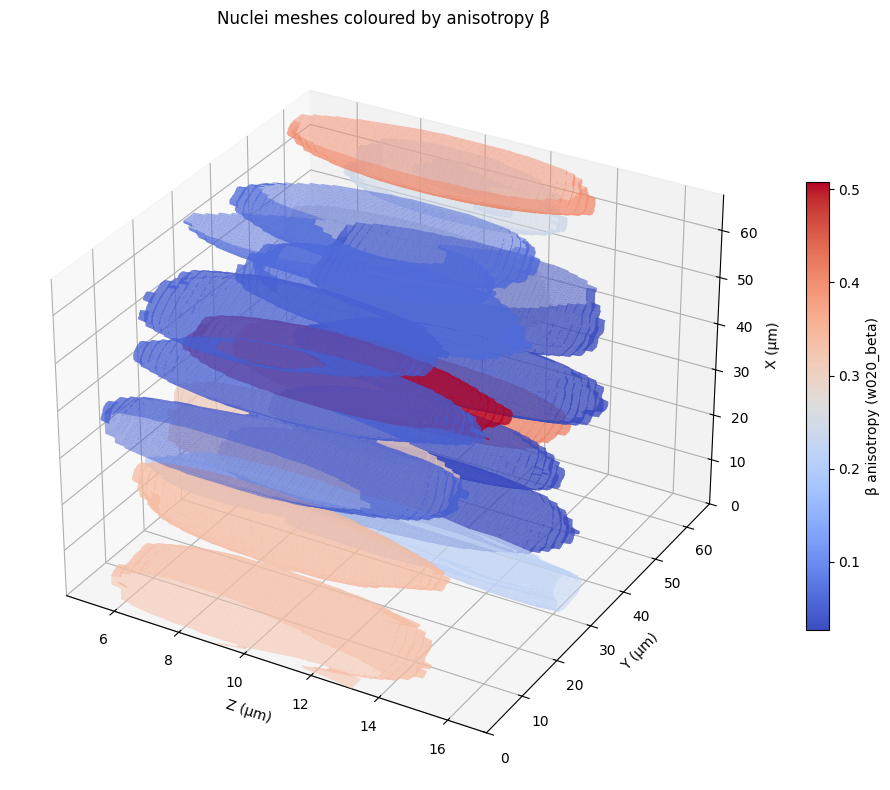

In [5]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

cmap = plt.colormaps['coolwarm']
betas = {lbl: results[lbl]['w020_beta'] for lbl in results}
vmin_b, vmax_b = min(betas.values()), max(betas.values())

all_verts_list = []
for lbl, r in sorted(results.items()):
    mask = (label_image == lbl).astype(np.float32)
    verts, faces, _, _ = measure.marching_cubes(mask, level=0.5, spacing=SPACING)
    all_verts_list.append(verts)
    color = cmap((betas[lbl] - vmin_b) / (vmax_b - vmin_b + 1e-9))
    mesh = Poly3DCollection(verts[faces], alpha=0.6, facecolor=color, edgecolor='none')
    ax.add_collection3d(mesh)

all_verts = np.vstack(all_verts_list)
ax.set_xlim(all_verts[:, 0].min(), all_verts[:, 0].max())
ax.set_ylim(all_verts[:, 1].min(), all_verts[:, 1].max())
ax.set_zlim(all_verts[:, 2].min(), all_verts[:, 2].max())

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin_b, vmax=vmax_b))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='β anisotropy (w020_beta)', shrink=0.6)

ax.set_title('Nuclei meshes coloured by anisotropy β')
ax.set_xlabel('Z (µm)')
ax.set_ylabel('Y (µm)')
ax.set_zlabel('X (µm)')
plt.tight_layout()
plt.show()

## PCA + Clustering

We build a feature vector for each nucleus from eight Minkowski quantities spanning volume, surface area, integrated mean and Gaussian curvature (scalars w200, w300), and the anisotropy and trace of the rank-2 tensors w020 and w102. After z-score standardisation we project onto two principal components and run K-Means (k = 2) to separate morphologically distinct populations.

In [6]:
feature_keys = ['w000', 'w100', 'w200', 'w300',
                 'w020_beta', 'w102_beta',
                 'w020_trace', 'w102_trace']

labels_sorted = sorted(results.keys())
X = np.array([[results[lbl][k] for k in feature_keys] for lbl in labels_sorted])
X_scaled = StandardScaler().fit_transform(X)

print(f"Feature matrix: {X_scaled.shape}  ({len(labels_sorted)} nuclei × {len(feature_keys)} features)")

Feature matrix: (12, 8)  (12 nuclei × 8 features)


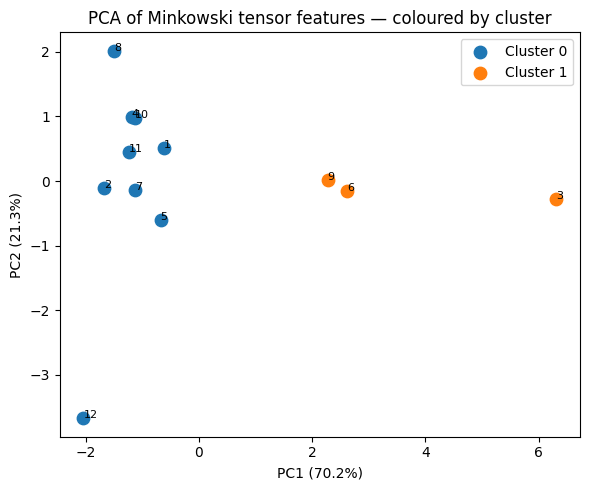

In [7]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

km = KMeans(n_clusters=2, random_state=0, n_init='auto').fit(X_pca)
cluster_labels = km.labels_

fig, ax = plt.subplots(figsize=(6, 5))
for c in np.unique(cluster_labels):
    idx = cluster_labels == c
    ax.scatter(X_pca[idx, 0], X_pca[idx, 1], label=f'Cluster {c}', s=80)
for i, lbl in enumerate(labels_sorted):
    ax.annotate(str(lbl), (X_pca[i, 0], X_pca[i, 1]), fontsize=8)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA of Minkowski tensor features — coloured by cluster')
ax.legend()
plt.tight_layout()
plt.show()

/opt/miniconda3/envs/pykarambola-0.3.0/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


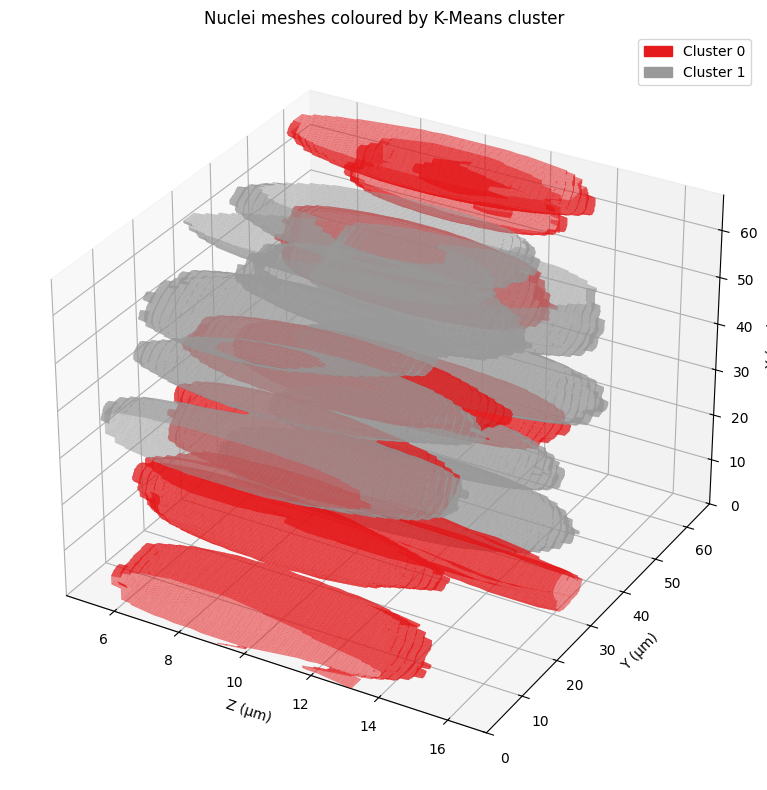

In [8]:
# map nucleus label → cluster colour
cluster_cmap = plt.colormaps['Set1']
lbl_to_cluster = {lbl: cluster_labels[i] for i, lbl in enumerate(labels_sorted)}
n_clusters = len(np.unique(cluster_labels))

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

all_verts_list2 = []
for lbl, r in sorted(results.items()):
    mask = (label_image == lbl).astype(np.float32)
    verts, faces, _, _ = measure.marching_cubes(mask, level=0.5, spacing=SPACING)
    all_verts_list2.append(verts)
    c_idx = lbl_to_cluster[lbl] / max(n_clusters - 1, 1)
    color = cluster_cmap(c_idx)
    mesh = Poly3DCollection(verts[faces], alpha=0.6, facecolor=color, edgecolor='none')
    ax.add_collection3d(mesh)

all_verts2 = np.vstack(all_verts_list2)
ax.set_xlim(all_verts2[:, 0].min(), all_verts2[:, 0].max())
ax.set_ylim(all_verts2[:, 1].min(), all_verts2[:, 1].max())
ax.set_zlim(all_verts2[:, 2].min(), all_verts2[:, 2].max())

patches = [mpatches.Patch(color=cluster_cmap(i / max(n_clusters - 1, 1)),
                           label=f'Cluster {i}') for i in range(n_clusters)]
ax.legend(handles=patches)
ax.set_title('Nuclei meshes coloured by K-Means cluster')
ax.set_xlabel('Z (µm)')
ax.set_ylabel('Y (µm)')
ax.set_zlabel('X (µm)')
plt.tight_layout()
plt.show()

## Summary

This notebook demonstrated a complete morphometry pipeline on real 3D fluorescence data:

| Step | Tool | What it captures |
|------|------|------------------|
| Load data | `skimage.data.cells3d` | 60-slice confocal stack, 2 channels |
| Segment nuclei | Gaussian + Otsu + connected components | Individual cell instances |
| Minkowski scalars (w000, w100, w200, w300) | `pykarambola` | Volume, surface area, integrated mean curvature, Euler characteristic |
| Rank-2 tensors (w020, w102) | `pykarambola` | Inertia tensor (shape elongation), curvature tensor (surface orientation) |
| Anisotropy β | derived from eigenvalues | 1 = sphere-like, < 1 = elongated/irregular |
| Mesh visualisation | marching cubes + `Poly3DCollection` | Colour-coded 3D shape rendering |
| PCA + K-Means | `sklearn` | Unsupervised morphotype discovery |

Minkowski tensors provide a compact, rotation-invariant description of 3D cell shape that goes beyond simple volume or surface area, capturing the full anisotropy and curvature distribution of each object.